In [75]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


In [76]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Reproducibility seed: {SEED}")

Reproducibility seed: 42


In [77]:
import kagglehub

path = kagglehub.dataset_download(
    "devavratatripathy/ecg-dataset"
)

print("Dataset path:", path)
print(os.listdir(path))

Dataset path: C:\Users\Romia\.cache\kagglehub\datasets\devavratatripathy\ecg-dataset\versions\1
['ecg.csv']


In [78]:
for root, dirs, files_list in os.walk(path):
    for file in files_list:
        print(os.path.join(root, file))

C:\Users\Romia\.cache\kagglehub\datasets\devavratatripathy\ecg-dataset\versions\1\ecg.csv


In [79]:
csv_path = os.path.join(path, "ecg.csv")

df = pd.read_csv(csv_path)

print(df.shape)
print(df.head())
print(df.columns)

(4997, 141)
   -0.11252183  -2.8272038  -3.7738969  -4.3497511  -4.376041  -3.4749863  \
0    -1.100878   -3.996840   -4.285843   -4.506579  -4.022377   -3.234368   
1    -0.567088   -2.593450   -3.874230   -4.584095  -4.187449   -3.151462   
2     0.490473   -1.914407   -3.616364   -4.318823  -4.268016   -3.881110   
3     0.800232   -0.874252   -2.384761   -3.973292  -4.338224   -3.802422   
4    -1.507674   -3.574550   -4.478011   -4.408275  -3.321242   -2.105171   

   -2.1814082  -1.8182865  -1.2505219  -0.47749208  ...  0.79216787  \
0   -1.566126   -0.992258   -0.754680     0.042321  ...    0.538356   
1   -1.742940   -1.490659   -1.183580    -0.394229  ...    0.886073   
2   -2.993280   -1.671131   -1.333884    -0.965629  ...    0.350816   
3   -2.534510   -1.783423   -1.594450    -0.753199  ...    1.148884   
4   -1.481048   -1.301362   -0.498240    -0.286928  ...    1.089068   

   0.93354122  0.79695779  0.57862066  0.2577399  0.22807718  0.12343082  \
0    0.656881    0.787

In [80]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDistribusi label:")
print(df.iloc[:, -1].value_counts())

Shape: (4997, 141)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Columns: 141 entries, -0.11252183 to 1.0
dtypes: float64(141)
memory usage: 5.4 MB
None

Missing values:
0

Distribusi label:
1.0
1.0    2918
0.0    2079
Name: count, dtype: int64


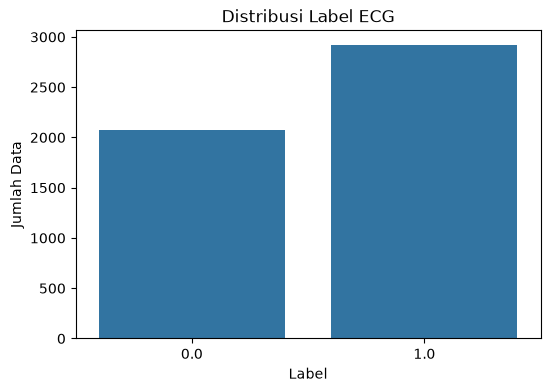

In [81]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df.iloc[:, -1]
)

plt.title("Distribusi Label ECG")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

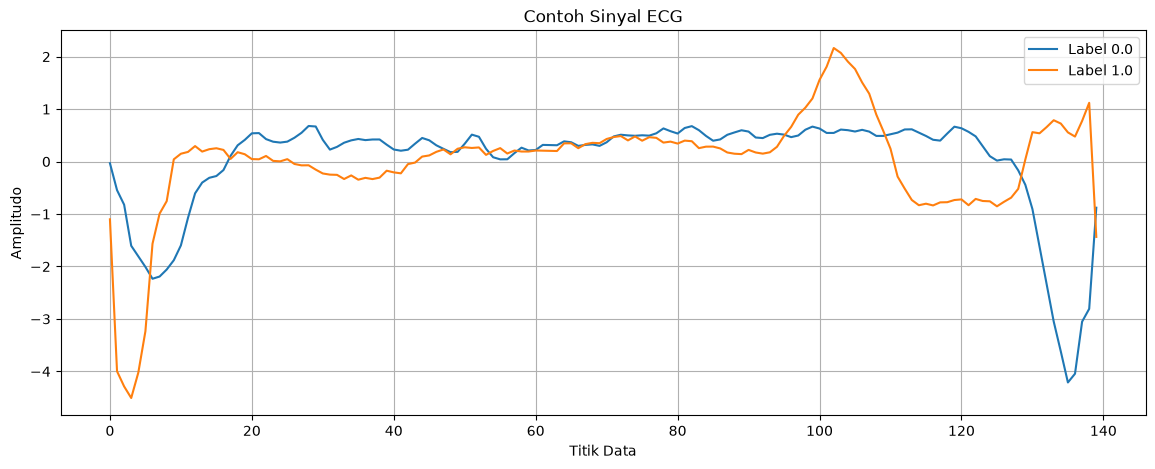

In [82]:
feature_columns = df.columns[:-1]
target_column = df.columns[-1]

plt.figure(figsize=(14, 5))

for label in sorted(df[target_column].unique()):

    sample = df[
        df[target_column] == label
    ].iloc[0][feature_columns].values

    plt.plot(
        sample,
        label=f"Label {label}"
    )

plt.title("Contoh Sinyal ECG")
plt.xlabel("Titik Data")
plt.ylabel("Amplitudo")
plt.legend()
plt.grid()
plt.show()

In [83]:
X = df[feature_columns].values.astype(np.float32)
y = df[target_column].values.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4997, 140)
y shape: (4997,)


In [84]:
X = df[feature_columns].values.astype(np.float32)
y = df[target_column].values.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4997, 140)
y shape: (4997,)


In [85]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1764705882,
    random_state=SEED,
    stratify=y_train_val
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print("Class proportions:")
print(pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
    "validation": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "test": pd.Series(y_test).value_counts(normalize=True).sort_index()
}))

Train: (3497, 140), Validation: (750, 140), Test: (750, 140)
Class proportions:
      train  validation   test
0  0.416071       0.416  0.416
1  0.583929       0.584  0.584


In [86]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("CNN input shapes:", X_train.shape, X_val.shape, X_test.shape)

CNN input shapes: (3497, 1, 140) (750, 1, 140) (750, 1, 140)


In [87]:
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [88]:
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

Batches: train=110, val=24, test=24


In [89]:
class ECG_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [90]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

model = ECG_CNN().to(DEVICE)

print(model)

Device: cuda
ECG_CNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
  

In [91]:
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5,
    min_lr=1e-6
)

print("Class weights:", class_weights.detach().cpu().numpy())

Class weights: [1.2017182  0.85626835]


In [92]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for inputs, labels in loader:

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

In [93]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = outputs.argmax(
                dim=1
            )

            total_loss += (
                loss.item() * inputs.size(0)
            )

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities[:, 1].cpu().numpy()
            )

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [94]:
EPOCHS = 50
PATIENCE = 8

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": []
}

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
                "seed": SEED
            },
            "best_ecg_cnn.pth"
        )
        print("Best validation checkpoint saved.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

Epoch [1/50] | Train Loss: 0.3121 | Train Acc: 0.8876 | Val Loss: 0.2140 | Val Acc: 0.8840 | LR: 1.00e-03
Best validation checkpoint saved.
Epoch [2/50] | Train Loss: 0.1280 | Train Acc: 0.9531 | Val Loss: 0.1089 | Val Acc: 0.9653 | LR: 1.00e-03
Best validation checkpoint saved.
Epoch [3/50] | Train Loss: 0.1020 | Train Acc: 0.9685 | Val Loss: 0.1291 | Val Acc: 0.9653 | LR: 1.00e-03
Epoch [4/50] | Train Loss: 0.0843 | Train Acc: 0.9714 | Val Loss: 0.0667 | Val Acc: 0.9800 | LR: 1.00e-03
Best validation checkpoint saved.
Epoch [5/50] | Train Loss: 0.0870 | Train Acc: 0.9731 | Val Loss: 0.0680 | Val Acc: 0.9787 | LR: 1.00e-03
Epoch [6/50] | Train Loss: 0.0706 | Train Acc: 0.9777 | Val Loss: 0.0855 | Val Acc: 0.9773 | LR: 1.00e-03
Epoch [7/50] | Train Loss: 0.0669 | Train Acc: 0.9794 | Val Loss: 0.0587 | Val Acc: 0.9800 | LR: 1.00e-03
Best validation checkpoint saved.
Epoch [8/50] | Train Loss: 0.0598 | Train Acc: 0.9806 | Val Loss: 0.0605 | Val Acc: 0.9813 | LR: 1.00e-03
Epoch [9/50] | T

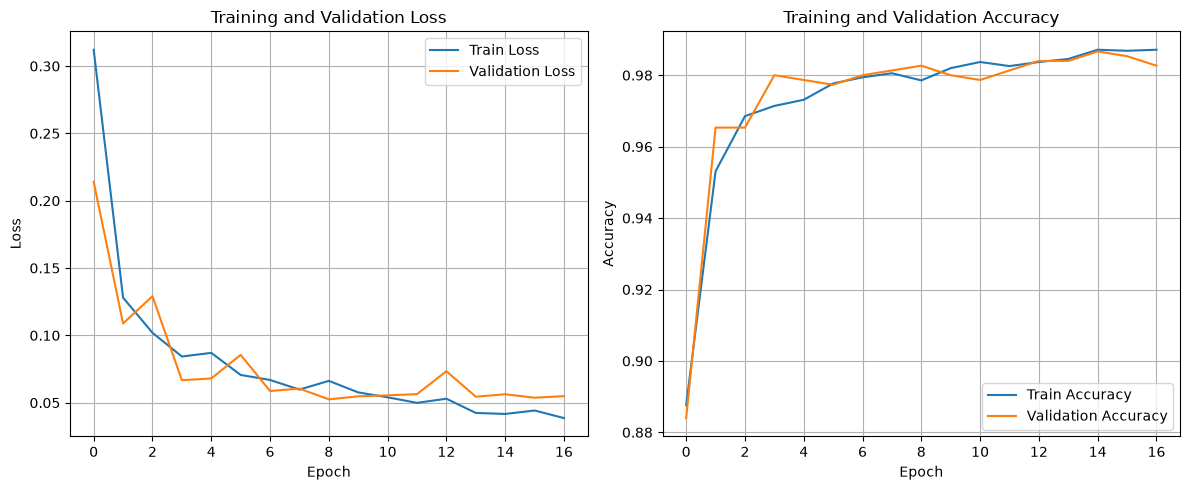

In [95]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [96]:
checkpoint = torch.load(
    "best_ecg_cnn.pth",
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(checkpoint["model_state_dict"])

final_test_loss, final_test_acc, y_true, y_pred, y_prob = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"PR-AUC: {average_precision_score(y_true, y_prob):.4f}")
print(f"MCC: {matthews_corrcoef(y_true, y_pred):.4f}")

Checkpoint epoch: 9
Test Loss: 0.0288
Test Accuracy: 99.07%
Balanced Accuracy: 0.9915
ROC-AUC: 0.9996
PR-AUC: 0.9997
MCC: 0.9809


In [97]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Normal",
            "Abnormal"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       312
    Abnormal       1.00      0.99      0.99       438

    accuracy                           0.99       750
   macro avg       0.99      0.99      0.99       750
weighted avg       0.99      0.99      0.99       750



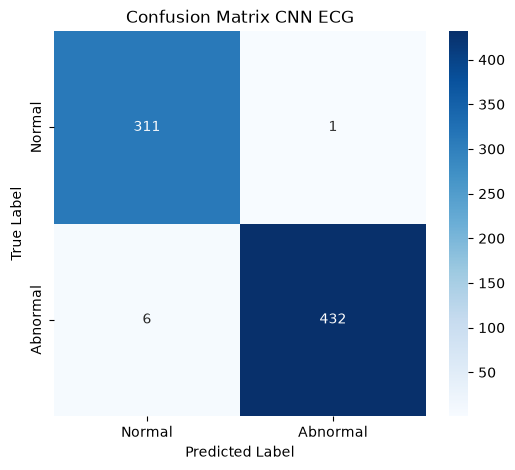

In [98]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Abnormal"
    ],
    yticklabels=[
        "Normal",
        "Abnormal"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix CNN ECG")
plt.show()